# NLP Lab: LSTM Classification + Seq2Seq

## Setup

In [2]:
import pandas as pd
import numpy as np
import random, math, time, copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


c:\Users\user\anaconda3\envs\ttest\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


---
# Part 1 — LSTM Classifier

## 1.1 Load & Inspect Data

We have three pre-split files: `train.csv`, `val.csv`, and `test.csv`.

- **Train** – used for all gradient updates.
- **Val (Dev)** – used during training to monitor generalisation and select the best checkpoint.
- **Test** – touched exactly once at the very end to report final numbers.

> Never use the test set to make any training decisions — not for early stopping, not for hyperparameter tuning. Its only role is a final honest evaluation.


In [10]:
train_df = pd.read_csv('./data/train.csv')
val_df   = pd.read_csv('./data/val.csv')
test_df  = pd.read_csv('./data/test.csv')

for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    counts = df['label'].value_counts().to_dict()
    print(f'{name:<5} : {len(df):>5} rows  |  {counts}')


Train :   801 rows  |  {'OBJ': 440, 'SUBJ': 361}
Val   :   246 rows  |  {'OBJ': 144, 'SUBJ': 102}
Test  :   250 rows  |  {'OBJ': 143, 'SUBJ': 107}


In [4]:
def print_data_distribution(df, label_col='label', text_col='sentence'):
    """Print class balance and text length statistics for one split."""
    print("=" * 50)
    print("CLASS DISTRIBUTION")
    print("=" * 50)
    counts = df[label_col].value_counts()
    total  = len(df)
    for label, count in counts.items():
        bar = "█" * int(count / total * 30)
        print(f"  {str(label):<8}  {count:>5} samples  ({count/total*100:.1f}%)  {bar}")
    print(f"\n  Total : {total} samples")

print_data_distribution(train_df)


CLASS DISTRIBUTION
  OBJ         440 samples  (54.9%)  ████████████████
  SUBJ        361 samples  (45.1%)  █████████████

  Total : 801 samples


## 1.2 Tokenisation

The tokenizer vocabulary is built **from the training set only** — fitting on val or test would be data leakage. Val and test sentences are then converted using that fixed vocabulary (unknown words map to `<unk>`).


In [5]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_LEN       = 30
MAX_FEATURES  = 5000
BATCH_SIZE    = 32
EMBEDDING_DIM = 64
HIDDEN_DIM    = 128

# Encode labels: OBJ=0, SUBJ=1
def encode_labels(df):
    return (df['label'] != 'OBJ').astype(np.float32).values

y_train = encode_labels(train_df)
y_val   = encode_labels(val_df)
y_test  = encode_labels(test_df)

# Fit tokenizer on train only
tokenizer = Tokenizer(num_words=MAX_FEATURES, oov_token='<unk>')
tokenizer.fit_on_texts(train_df['sentence'].values)

def tokenize(texts):
    return pad_sequences(tokenizer.texts_to_sequences(texts), maxlen=MAX_LEN)

X_train = tokenize(train_df['sentence'].values)
X_val   = tokenize(val_df['sentence'].values)
X_test  = tokenize(test_df['sentence'].values)

word2idx = tokenizer.word_index
idx2word = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = min(MAX_FEATURES, len(word2idx)) + 1  # +1 for padding idx 0

print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"Train / Val / Test : {len(X_train)} / {len(X_val)} / {len(X_test)}")


Vocabulary size : 5001
Train / Val / Test : 801 / 246 / 250


## 1.3 Dataset & DataLoader

In [8]:
class SubjSentence(Dataset):
    def __init__(self, x, y):
        self.x = torch.LongTensor(x)
        self.y = torch.FloatTensor(y)
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_dataset = SubjSentence(X_train, y_train)
val_dataset   = SubjSentence(X_val,   y_val)
test_dataset  = SubjSentence(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)


## 1.4 LSTM Classifier

The model:
1. **Embedding** – maps each token index to a dense vector.
2. **LSTM** – processes the sequence left-to-right, building up context.
3. **Dropout** – regularisation.
4. **Linear projection** – maps the *last* hidden state to a single logit for binary classification.


In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm      = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        emb    = self.dropout(self.embedding(x))
        # output, (hidden, cell)
        out, _ = self.lstm(emb)
        last   = out[:, -1, :]          # final timestep hidden state
        return self.fc(self.dropout(last))

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

clf_model = LSTMClassifier(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(device)
clf_optimizer = optim.Adam(clf_model.parameters(), lr=1e-3)
clf_loss_fn   = nn.BCEWithLogitsLoss()
print(f"Trainable parameters: {count_params(clf_model):,}")


Trainable parameters: 419,521


## 1.5 Training with Best-Checkpoint Saving

We train for 50 epochs but save the model weights whenever the **validation loss improves**. At the end we restore those best weights before evaluating on the test set.

In [11]:
def train_classifier(model, train_loader, val_loader, optimizer, loss_fn, epochs=50):
    train_history = []
    val_history   = []
    best_val_loss = float('inf')
    best_weights  = None

    for epoch in range(1, epochs + 1):
        # ── Train ──
        model.train()
        epoch_loss = 0
        for x, y in tqdm(train_loader, desc=f"Epoch {epoch:02d}", leave=False):
            x, y = x.to(device), y.unsqueeze(1).to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_avg = epoch_loss / len(train_loader)

        # ── Validate ──
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.unsqueeze(1).to(device)
                val_loss += loss_fn(model(x), y).item()
        val_avg = val_loss / len(val_loader)

        train_history.append(train_avg)
        val_history.append(val_avg)

        # ── Save best checkpoint ──
        if val_avg < best_val_loss:
            best_val_loss = val_avg
            best_weights  = copy.deepcopy(model.state_dict())
            tag = " ← best"
        else:
            tag = ""

        #if epoch % 5 == 0 or epoch == 1:
        # print(f"Epoch {epoch:02d} | Train: {train_avg:.4f}  Val: {val_avg:.4f}")
        print(f"Epoch {epoch:02d} | Train: {train_avg:.4f}  Val: {val_avg:.4f}{tag}")

    # Restore best weights
    model.load_state_dict(best_weights)
    print(f"\nRestored best checkpoint (val loss: {best_val_loss:.4f})")
    return train_history, val_history

clf_train_hist, clf_val_hist = train_classifier(
    clf_model, train_loader, val_loader, clf_optimizer, clf_loss_fn, epochs=50
)


Epoch 01 | Train: 0.6904  Val: 0.6929 ← best


Epoch 02 | Train: 0.6706  Val: 0.6802 ← best


Epoch 03 | Train: 0.6557  Val: 0.6794 ← best


Epoch 04 | Train: 0.6574  Val: 0.6710 ← best


Epoch 05 | Train: 0.6132  Val: 0.7188


...

Epoch 46 | Train: 0.0118  Val: 1.8316


Epoch 47 | Train: 0.0097  Val: 1.8974


Epoch 48 | Train: 0.0135  Val: 1.9754


Epoch 49 | Train: 0.0190  Val: 2.0013


Epoch 50 | Train: 0.0217  Val: 1.9590

Restored best checkpoint (val loss: 0.6710)


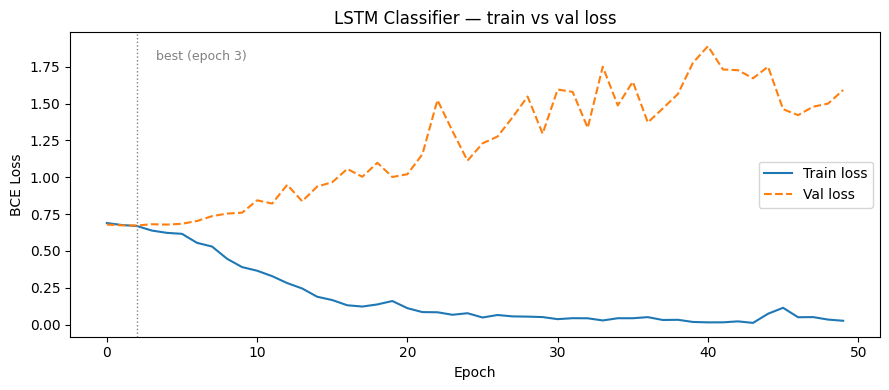

In [23]:
# Plot train vs val loss — the gap shows overfitting onset
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(clf_train_hist, label='Train loss')
ax.plot(clf_val_hist,   label='Val loss',  linestyle='--')
best_epoch = int(np.argmin(clf_val_hist)) + 1
ax.axvline(best_epoch - 1, color='gray', linestyle=':', linewidth=1)
ax.text(best_epoch, max(clf_val_hist)*0.95, f' best (epoch {best_epoch})',
        fontsize=9, color='gray')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('LSTM Classifier — train vs val loss')
ax.legend()
plt.tight_layout()
plt.show()


## 1.6 Evaluation on Test Set

We evaluate the best checkpoint (restored above) on the held-out test set.


In [25]:
def evaluate_classifier(model, loader, device, label="", threshold=0.5):
    """Accuracy + F1 on any DataLoader. Returns a metrics dict."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(device)).squeeze(1)
            preds  = (torch.sigmoid(logits).cpu() >= threshold).long()
            all_preds.extend(preds.tolist())
            all_labels.extend(y.long().tolist())

    acc = accuracy_score(all_labels, all_preds)
    f1m = f1_score(all_labels, all_preds, average='macro')
    f1w = f1_score(all_labels, all_preds, average='weighted')

    header = f"EVALUATION — {label}" if label else "EVALUATION"
    print("=" * 50)
    print(header)
    print("=" * 50)
    print(f"  Accuracy   : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  F1 macro   : {f1m:.4f}")
    print(f"  F1 weighted: {f1w:.4f}")
    print()
    print(classification_report(all_labels, all_preds,
                                target_names=['OBJ (0)', 'SUBJ (1)']))
    return {'accuracy': acc, 'f1_macro': f1m, 'f1_weighted': f1w}

clf_results = evaluate_classifier(clf_model, test_loader, device, label="LSTM Classifier (Part 1)")


EVALUATION — LSTM Classifier (Part 1)
  Accuracy   : 0.5880  (58.80%)
  F1 macro   : 0.5581
  F1 weighted: 0.5747

              precision    recall  f1-score   support

     OBJ (0)       0.62      0.74      0.67       143
    SUBJ (1)       0.53      0.38      0.44       107

    accuracy                           0.59       250
   macro avg       0.57      0.56      0.56       250
weighted avg       0.58      0.59      0.57       250



---
Visualising Hidden States

The LSTM produces a hidden state vector at every timestep. Plotting these as a heatmap reveals which tokens the model reacts to most strongly — a first glimpse into what the network has learned.


Sentence: "Трудно е класически оркестър и рок банда да свирят заедно, имаме физически проблеми, защото една рок група, колкото и да свири тихо, тя все пак е силна."


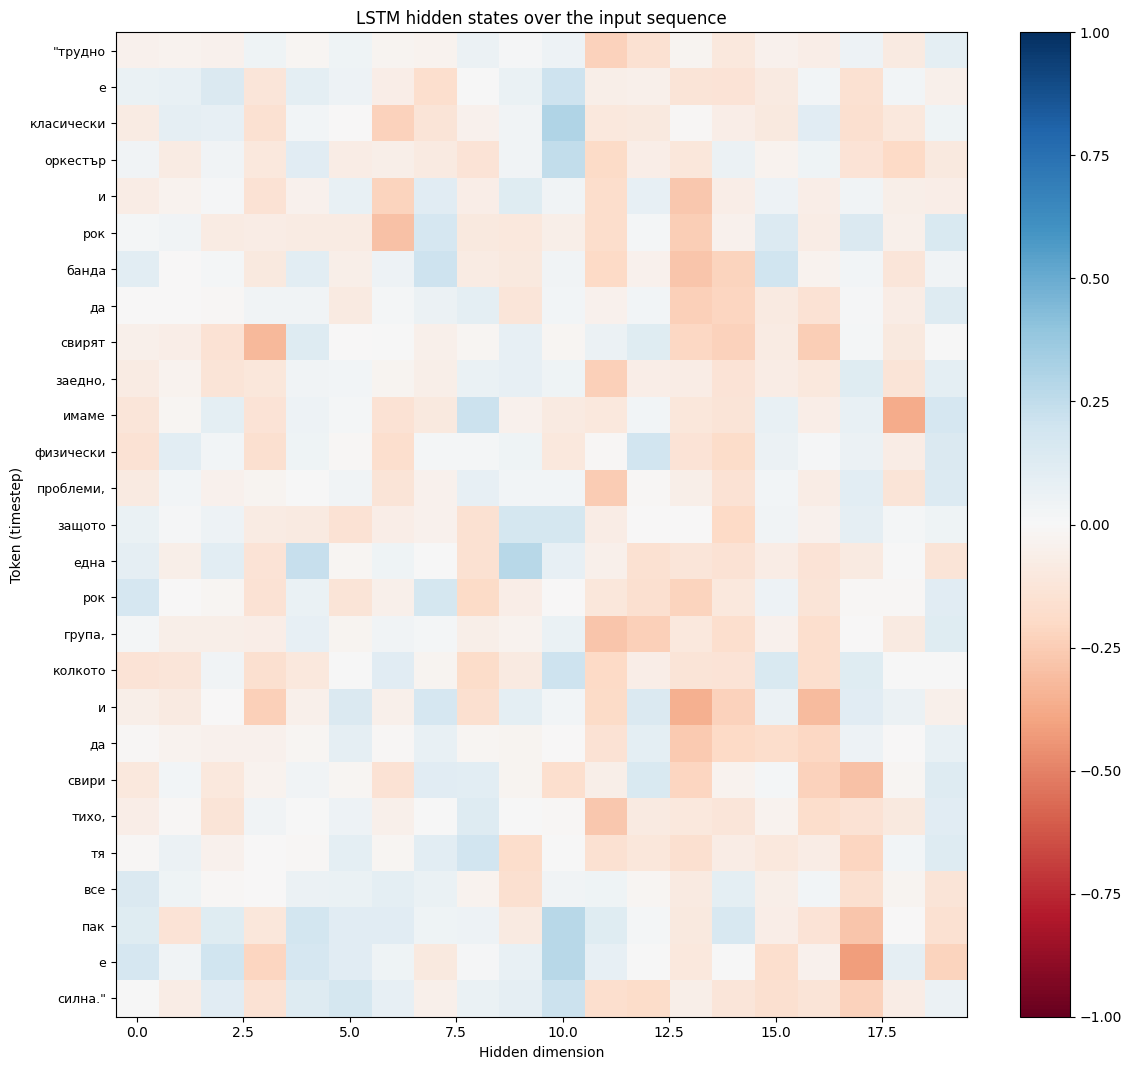

In [12]:
def plot_hidden_states(model, sentence_str, word2idx, max_len=MAX_LEN, n_dims=20):
    model.eval()
    tokens = sentence_str.lower().split()[:max_len]
    ids    = [word2idx.get(t, 1) for t in tokens] + [0] * (max_len - len(tokens))
    x      = torch.LongTensor([ids]).to(device)

    with torch.no_grad():
        emb        = model.embedding(x)
        out, _     = model.lstm(emb)
        hidden_seq = out[0].cpu().numpy()

    data = hidden_seq[:len(tokens), :n_dims]

    fig, ax = plt.subplots(figsize=(12, max(3, len(tokens) * 0.4)))
    im = ax.imshow(data, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=9)
    ax.set_xlabel("Hidden dimension")
    ax.set_ylabel("Token (timestep)")
    ax.set_title("LSTM hidden states over the input sequence")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

example = train_df['sentence'].values[0]
print("Sentence:", example)
plot_hidden_states(clf_model, example, word2idx)


> **What to notice:** Bright red/blue cells mark positions where the model activates strongly. Try sentences from opposite classes — do the activation patterns differ? The pattern evolves left-to-right as context accumulates.


---
# Part 2 — Seq2Seq Autoencoder

## Why an autoencoder?

Before using seq2seq for classification (Part 3), we first train it on the simplest possible task: **reconstruct the input sentence**. This isolates the architecture from task complexity — if the model can't reconstruct, it definitely can't classify.

The encoder compresses the full sentence into a **context vector** $z$ (the final hidden + cell state). The decoder then generates tokens one-by-one from $z$.

## 2.1 Special tokens and dataset


In [13]:
SOS_IDX   = VOCAB_SIZE
EOS_IDX   = VOCAB_SIZE + 1
S2S_VOCAB = VOCAB_SIZE + 2
MAX_TRG_LEN = MAX_LEN + 2

class Seq2SeqDataset(Dataset):
    """src and trg are the same sentence; trg is wrapped with <sos>/<eos>."""
    def __init__(self, sequences):
        self.data = sequences
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        src     = list(self.data[idx])
        stripped = [t for t in src if t != 0]
        trg      = ([SOS_IDX] + stripped + [EOS_IDX])[:MAX_TRG_LEN]
        trg     += [0] * (MAX_TRG_LEN - len(trg))
        return torch.LongTensor(src), torch.LongTensor(trg)

s2s_train_loader = DataLoader(Seq2SeqDataset(X_train), batch_size=BATCH_SIZE, shuffle=True)
s2s_val_loader   = DataLoader(Seq2SeqDataset(X_val),   batch_size=BATCH_SIZE)
s2s_test_loader  = DataLoader(Seq2SeqDataset(X_test),  batch_size=BATCH_SIZE)


## 2.2 Encoder

In [ ]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.rnn       = nn.LSTM(emb_dim, hid_dim, batch_first=True)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        _, (hidden, cell) = self.rnn(embedded)
        return hidden, cell  # context vector z
    
    #Encoder -> Linear(DIM_SIZE,1) -> Prediction 0 |1


## 2.3 Decoder

In [ ]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.rnn       = nn.LSTM(emb_dim, hid_dim, batch_first=True)
        self.fc_out    = nn.Linear(hid_dim, vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, token, hidden, cell):
        token    = token.unsqueeze(1)
        embedded = self.dropout(self.embedding(token))
        out, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        pred = self.fc_out(out.squeeze(1))
        return pred, hidden, cell

# Decoder -> 0 | 1 <eos>

## 2.4 Seq2Seq wrapper

`teacher_forcing_ratio` controls how often the decoder receives the true previous token vs its own prediction. See Exploration B for why this matters.


In [29]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, sos_idx, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.sos_idx = sos_idx
        self.device  = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        B, trg_len  = trg.shape
        vocab_size   = self.decoder.fc_out.out_features
        outputs      = torch.zeros(B, trg_len, vocab_size).to(self.device)
        hidden, cell = self.encoder(src)
        dec_input    = trg[:, 0]   # <sos>

        for t in range(1, trg_len):
            pred, hidden, cell = self.decoder(dec_input, hidden, cell)
            outputs[:, t, :]   = pred
            use_teacher        = random.random() < teacher_forcing_ratio
            dec_input          = trg[:, t] if use_teacher else pred.argmax(1)

        return outputs


## 2.5 Shared training and evaluation utilities

In [30]:
CLIP = 1.0

def train_s2s(model, loader, optimizer, criterion, epochs=5, tf_ratio=0.5):
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0
        for src, trg in tqdm(loader, desc=f"Epoch {epoch}", leave=False):
            src, trg = src.to(device), trg.to(device)
            optimizer.zero_grad()
            out      = model(src, trg, teacher_forcing_ratio=tf_ratio)
            out_flat = out[:, 1:, :].reshape(-1, out.shape[-1])
            trg_flat = trg[:, 1:].reshape(-1)
            loss     = criterion(out_flat, trg_flat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CLIP)
            optimizer.step()
            epoch_loss += loss.item()
        avg = epoch_loss / len(loader)
        history.append(avg)
        print(f"  [tf={tf_ratio}] Epoch {epoch:02d} | Loss: {avg:.4f} | PPL: {math.exp(avg):.2f}")
    return history


def evaluate_s2s(model, loader, criterion, device, label="model"):
    """Loss + perplexity on any DataLoader. Always uses tf=0 (honest eval)."""
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, trg in loader:
            src, trg = src.to(device), trg.to(device)
            out      = model(src, trg, teacher_forcing_ratio=0.0)
            out_flat = out[:, 1:, :].reshape(-1, out.shape[-1])
            trg_flat = trg[:, 1:].reshape(-1)
            epoch_loss += criterion(out_flat, trg_flat).item()
    avg_loss   = epoch_loss / len(loader)
    perplexity = math.exp(avg_loss)
    print(f"[{label}]  Loss: {avg_loss:.4f}  PPL: {perplexity:.2f}")
    return {'loss': avg_loss, 'perplexity': perplexity}


## 2.6 Train the autoencoder

In [31]:
ENC_EMB_DIM = 64
DEC_EMB_DIM = 64
HID_DIM_S2S = 256

def init_weights(m):
    for p in m.parameters():
        nn.init.uniform_(p.data, -0.08, 0.08)

def make_s2s():
    enc = Encoder(S2S_VOCAB, ENC_EMB_DIM, HID_DIM_S2S).to(device)
    dec = Decoder(S2S_VOCAB, DEC_EMB_DIM, HID_DIM_S2S).to(device)
    m   = Seq2Seq(enc, dec, SOS_IDX, device).to(device)
    m.apply(init_weights)
    return m

s2s = make_s2s()
s2s_optimizer = optim.Adam(s2s.parameters(), lr=1e-3)
s2s_criterion = nn.CrossEntropyLoss(ignore_index=0)
print(f"Seq2Seq parameters: {count_params(s2s):,}")

hist_s2s = train_s2s(s2s, s2s_train_loader, s2s_optimizer, s2s_criterion, epochs=5, tf_ratio=0.5)


Seq2Seq parameters: 2,585,611


  [tf=0.5] Epoch 01 | Loss: 7.8175 | PPL: 2483.79


  [tf=0.5] Epoch 02 | Loss: 6.8994 | PPL: 991.71


  [tf=0.5] Epoch 03 | Loss: 6.7946 | PPL: 893.00


  [tf=0.5] Epoch 04 | Loss: 6.7103 | PPL: 820.81


  [tf=0.5] Epoch 05 | Loss: 6.6214 | PPL: 751.01


---
# Teacher Forcing

We train two versions (TF=1.0 and TF=0.0) and compare their training loss curves.

**The core tension:**
- `TF=1.0` — fast, stable training but the decoder never sees its own mistakes → *exposure bias* at inference.
- `TF=0.0` — slow, noisy training but no exposure bias → better match to how the model is actually used.

The loss curves make this tradeoff concrete: TF=1.0 will drop faster, but TF=0.0 may generalise better.


In [ ]:

# Decoding -> T1(C) T2(C) T3(C) T4(C) T5(C) T6(C) ?



# Decoding -> T1(C) T2(E) T3(E) T4(C) T5(E) T6(C) T7(E)

TF = 0 # Decoding -> T1(?) T2(?) T3(?) T4(?) T5(?) T6(?) T7(?)) <eos>



TF=0.5
s2s_tf1 = make_s2s()
opt_tf1 = optim.Adam(s2s_tf1.parameters(), lr=1e-3)
print("=== TF = 1.0 ===")
hist_tf1 = train_s2s(s2s_tf1, s2s_train_loader, opt_tf1, s2s_criterion, epochs=5, tf_ratio=1.0)

s2s_tf0 = make_s2s()
opt_tf0 = optim.Adam(s2s_tf0.parameters(), lr=1e-3)
print("\n=== TF = 0.0 ===")
hist_tf0 = train_s2s(s2s_tf0, s2s_train_loader, opt_tf0, s2s_criterion, epochs=5, tf_ratio=0.0)


=== TF = 1.0 ===


  [tf=1.0] Epoch 01 | Loss: 7.8119 | PPL: 2469.79


  [tf=1.0] Epoch 02 | Loss: 6.8470 | PPL: 941.02


  [tf=1.0] Epoch 03 | Loss: 6.7276 | PPL: 835.11


  [tf=1.0] Epoch 04 | Loss: 6.6101 | PPL: 742.56


...

  [tf=0.0] Epoch 01 | Loss: 7.8342 | PPL: 2525.59


  [tf=0.0] Epoch 02 | Loss: 6.9135 | PPL: 1005.77


  [tf=0.0] Epoch 03 | Loss: 6.7893 | PPL: 888.31


  [tf=0.0] Epoch 04 | Loss: 6.6761 | PPL: 793.20


  [tf=0.0] Epoch 05 | Loss: 6.6027 | PPL: 737.09


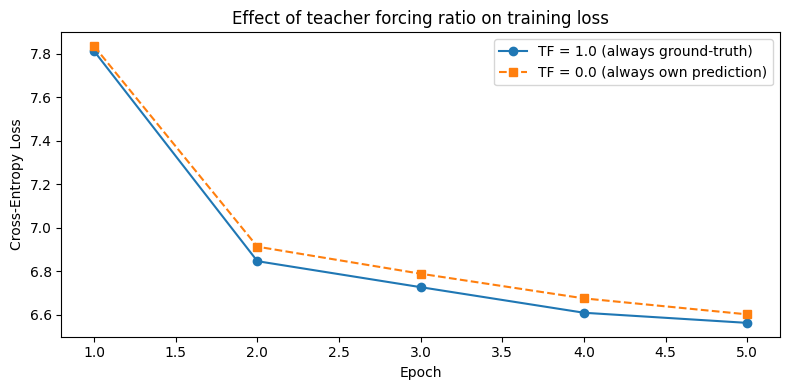

In [33]:
ep = range(1, 6)
plt.figure(figsize=(8, 4))
plt.plot(ep, hist_tf1, 'o-',  label='TF = 1.0 (always ground-truth)')
plt.plot(ep, hist_tf0, 's--', label='TF = 0.0 (always own prediction)')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Effect of teacher forcing ratio on training loss')
plt.legend()
plt.tight_layout()
plt.show()


> In practice, **scheduled teacher forcing** starts at 1.0 and decays toward 0.0 over training — getting stable early convergence while closing the gap to inference conditions.


---
# Perplexity

$$\text{PPL} = e^{\text{Cross-Entropy Loss}}$$

PPL measures how "surprised" the model is by the data. An untrained model over vocabulary size $V$ has PPL ≈ $V$. Lower is better; PPL = 1 means perfect prediction.


In [34]:
print("Autoencoder evaluation on test set:")
r_tf1 = evaluate_s2s(s2s_tf1, s2s_test_loader, s2s_criterion, device, label="TF=1.0")
r_tf0 = evaluate_s2s(s2s_tf0, s2s_test_loader, s2s_criterion, device, label="TF=0.0")
print(f"\nUntrained baseline PPL ≈ {S2S_VOCAB}  (uniform over vocab)")


Autoencoder evaluation on test set:
[TF=1.0]  Loss: 5.5397  PPL: 254.60
[TF=0.0]  Loss: 5.3498  PPL: 210.57

Untrained baseline PPL ≈ 5003  (uniform over vocab)


---
# Seq2Seq Classifier

## The idea

We now repurpose the seq2seq architecture for **classification**. Instead of decoding a full reconstructed sentence, the decoder only needs to generate a single label token: `"subj"` or `"obj"`.

The target sequence is just `[<sos>, label_token, <eos>]` — length 3. Everything else (encoder, decoder, training loop) is unchanged.

## Why does this work?

The encoder still reads the full sentence and compresses it into a context vector $z$. The decoder, instead of unpacking $z$ into a sentence, only needs to pick one of two tokens from $z$. It is a deliberately over-engineered classifier — and that is the point.

## What this teaches

Comparing Part 1 and Part 3 reveals something fundamental. Both models share the **same encoder structure**. The only difference is the head attached to it:

| | Part 1 LSTM Classifier | Part 3 Seq2Seq Classifier |
|---|---|---|
| Encoder | LSTM → last hidden state | LSTM → context vector |
| Head | Single linear layer | Full autoregressive decoder |
| Output | 1 logit | 1 token from vocab |
| Parameters | Few | Many |

This is the foundation of **pretrain → finetune**: a shared encoder can serve multiple downstream tasks by swapping heads. The seq2seq approach is overkill for binary classification, and the metrics at the end will show that — but building both makes the architecture reuse principle explicit.

## 3.1 Classification tokens and dataset


In [36]:
# Add two label tokens to the vocabulary
SUBJ_IDX  = S2S_VOCAB      # token for "subjective"
OBJ_IDX   = S2S_VOCAB + 1  # token for "objective"
CLF_VOCAB = S2S_VOCAB + 2  # total vocabulary for classifier model

# Map float label (0.0/1.0) → token index
def label_to_idx(y_float):
    return SUBJ_IDX if y_float == 1.0 else OBJ_IDX

class Seq2SeqClfDataset(Dataset):
    """
    src  = padded sentence (same as before)
    trg  = [<sos>, label_token, <eos>]  — fixed length 3
    """
    def __init__(self, sequences, labels):
        self.seqs   = sequences
        self.labels = labels

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        src = torch.LongTensor(self.seqs[idx])
        trg = torch.LongTensor([SOS_IDX,
                                 label_to_idx(self.labels[idx]),
                                 EOS_IDX])
        return src, trg

clf_s2s_train = Seq2SeqClfDataset(X_train, y_train)
clf_s2s_val   = Seq2SeqClfDataset(X_val,   y_val)
clf_s2s_test  = Seq2SeqClfDataset(X_test,  y_test)

clf_s2s_train_loader = DataLoader(clf_s2s_train, batch_size=BATCH_SIZE, shuffle=True)
clf_s2s_val_loader   = DataLoader(clf_s2s_val,   batch_size=BATCH_SIZE)
clf_s2s_test_loader  = DataLoader(clf_s2s_test,  batch_size=BATCH_SIZE)

# Sanity check
src_ex, trg_ex = clf_s2s_train[0]
print("src:", src_ex[:8].tolist(), "...")
print("trg:", trg_ex.tolist(), "  (sos, label, eos)")
print(f"SUBJ token={SUBJ_IDX}, OBJ token={OBJ_IDX}")


src: [0, 0, 0, 169, 8, 1321, 1322, 3] ...
trg: [5001, 5004, 5002]   (sos, label, eos)
SUBJ token=5003, OBJ token=5004


## 3.2 Build the model

We use the same `Encoder` and `Decoder` classes from Part 2 — only the vocabulary size changes (2 extra label tokens). The decoder will learn to emit either `SUBJ_IDX` or `OBJ_IDX` as its first (and only) meaningful output token.


In [43]:
enc_clf = Encoder(CLF_VOCAB, ENC_EMB_DIM, HID_DIM_S2S).to(device)
dec_clf = Decoder(CLF_VOCAB, DEC_EMB_DIM, HID_DIM_S2S).to(device)
s2s_clf = Seq2Seq(enc_clf, dec_clf, SOS_IDX, device).to(device)
s2s_clf.apply(init_weights)

s2s_clf_optimizer = optim.Adam(s2s_clf.parameters(), lr=1e-3)
s2s_clf_criterion = nn.CrossEntropyLoss(ignore_index=0)

print(f"Seq2Seq classifier parameters: {count_params(s2s_clf):,}")
print(f"(vs LSTM classifier: {count_params(clf_model):,})")


Seq2Seq classifier parameters: 2,586,381
(vs LSTM classifier: 419,521)


## 3.3 Training with best checkpoint

We reuse the same best-checkpoint pattern from Part 1 — monitor val loss, keep the best weights. Teacher forcing is always 1.0 here: the target is only one token long so there is no multi-step exposure bias to worry about.


In [44]:
def train_s2s_clf(model, train_loader, val_loader, optimizer, criterion, epochs=50):
    train_history, val_history = [], []
    best_val_loss = float('inf')
    best_weights  = None

    for epoch in range(1, epochs + 1):
        # ── Train ──
        model.train()
        epoch_loss = 0
        for src, trg in tqdm(train_loader, desc=f"Epoch {epoch:02d}", leave=False):
            src, trg = src.to(device), trg.to(device)
            optimizer.zero_grad()
            out      = model(src, trg, teacher_forcing_ratio=1.0)
            # Only position 1 matters (the label token)
            out_flat = out[:, 1:, :].reshape(-1, out.shape[-1])
            trg_flat = trg[:, 1:].reshape(-1)
            loss     = criterion(out_flat, trg_flat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CLIP)
            optimizer.step()
            epoch_loss += loss.item()
        train_avg = epoch_loss / len(train_loader)

        # ── Validate ──
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for src, trg in val_loader:
                src, trg = src.to(device), trg.to(device)
                out      = model(src, trg, teacher_forcing_ratio=0.0)
                out_flat = out[:, 1:, :].reshape(-1, out.shape[-1])
                trg_flat = trg[:, 1:].reshape(-1)
                val_loss += criterion(out_flat, trg_flat).item()
        val_avg = val_loss / len(val_loader)

        train_history.append(train_avg)
        val_history.append(val_avg)

        if val_avg < best_val_loss:
            best_val_loss = val_avg
            best_weights  = copy.deepcopy(model.state_dict())
            tag = " ← best"
        else:
            tag = ""

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:02d} | Train: {train_avg:.4f}  Val: {val_avg:.4f}{tag}")

    model.load_state_dict(best_weights)
    print(f"\nRestored best checkpoint (val loss: {best_val_loss:.4f})")
    return train_history, val_history

s2s_clf_train_hist, s2s_clf_val_hist = train_s2s_clf(
    s2s_clf, clf_s2s_train_loader, clf_s2s_val_loader,
    s2s_clf_optimizer, s2s_clf_criterion, epochs=50
)


Epoch 01 | Train: 3.9897  Val: 0.4328 ← best


Epoch 05 | Train: 0.3557  Val: 0.3420 ← best


Epoch 10 | Train: 0.0687  Val: 0.5623


Epoch 15 | Train: 0.0164  Val: 0.5462


Epoch 20 | Train: 0.0035  Val: 0.6583


...

Epoch 30 | Train: 0.0004  Val: 0.7845


Epoch 35 | Train: 0.0003  Val: 0.8289


Epoch 40 | Train: 0.0002  Val: 0.8727


Epoch 45 | Train: 0.0002  Val: 0.9691


Epoch 50 | Train: 0.0001  Val: 0.9260

Restored best checkpoint (val loss: 0.3420)


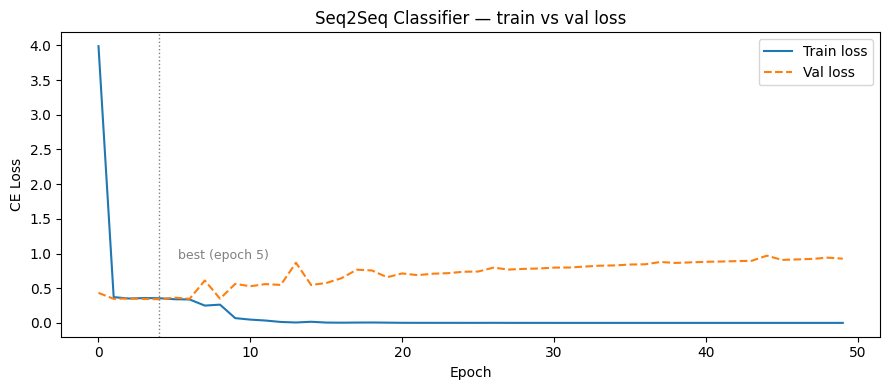

In [46]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(s2s_clf_train_hist, label='Train loss')
ax.plot(s2s_clf_val_hist,   label='Val loss', linestyle='--')
best_epoch = int(np.argmin(s2s_clf_val_hist)) + 1
ax.axvline(best_epoch - 1, color='gray', linestyle=':', linewidth=1)
ax.text(best_epoch, max(s2s_clf_val_hist)*0.95,
        f' best (epoch {best_epoch})', fontsize=9, color='gray')
ax.set_xlabel('Epoch')
ax.set_ylabel('CE Loss')
ax.set_title('Seq2Seq Classifier — train vs val loss')
ax.legend()
plt.tight_layout()
plt.show()


## 3.4 Evaluation

To get accuracy and F1 from a seq2seq model we read the predicted token at decoder position 1 and map it back to 0/1.


In [47]:
def evaluate_s2s_classifier(model, loader, device, label="", threshold=None):
    """
    Evaluate a Seq2Seq trained for single-token classification.
    Reads the argmax at decoder step 1 and maps SUBJ_IDX→1, OBJ_IDX→0.
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for src, trg in loader:
            src, trg = src.to(device), trg.to(device)
            out  = model(src, trg, teacher_forcing_ratio=0.0)  # (B, 3, V)
            # Position 1 is the label prediction
            pred_tokens = out[:, 1, :].argmax(1).cpu()
            # Map token → binary label
            preds = (pred_tokens == SUBJ_IDX).long()
            all_preds.extend(preds.tolist())
            all_labels.extend((trg[:, 1].cpu() == SUBJ_IDX).long().tolist())

    acc = accuracy_score(all_labels, all_preds)
    f1m = f1_score(all_labels, all_preds, average='macro')
    f1w = f1_score(all_labels, all_preds, average='weighted')

    header = f"EVALUATION — {label}" if label else "EVALUATION"
    print("=" * 50)
    print(header)
    print("=" * 50)
    print(f"  Accuracy   : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  F1 macro   : {f1m:.4f}")
    print(f"  F1 weighted: {f1w:.4f}")
    print()
    print(classification_report(all_labels, all_preds,
                                target_names=['OBJ (0)', 'SUBJ (1)']))
    return {'accuracy': acc, 'f1_macro': f1m, 'f1_weighted': f1w}

s2s_clf_results = evaluate_s2s_classifier(
    s2s_clf, clf_s2s_test_loader, device, label="Seq2Seq Classifier (Part 3)"
)


EVALUATION — Seq2Seq Classifier (Part 3)
  Accuracy   : 0.5720  (57.20%)
  F1 macro   : 0.3639
  F1 weighted: 0.4163

              precision    recall  f1-score   support

     OBJ (0)       0.57      1.00      0.73       143
    SUBJ (1)       0.00      0.00      0.00       107

    accuracy                           0.57       250
   macro avg       0.29      0.50      0.36       250
weighted avg       0.33      0.57      0.42       250



c:\Users\user\anaconda3\envs\ttest\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\anaconda3\envs\ttest\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\anaconda3\envs\ttest\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

---
# LSTM Classifier vs Seq2Seq Classifier

Both models read the same sentences with the same vocabulary. The only difference is the prediction head.


In [48]:
print(f"{'Model':<30} {'Accuracy':>10} {'F1 macro':>10} {'F1 weighted':>12} {'Params':>10}")
print("-" * 76)
for label, results, model in [
    ("LSTM Classifier",      clf_results,     clf_model),
    ("Seq2Seq Classifier",   s2s_clf_results, s2s_clf),
]:
    print(f"{label:<30} "
          f"{results['accuracy']:>10.4f} "
          f"{results['f1_macro']:>10.4f} "
          f"{results['f1_weighted']:>12.4f} "
          f"{count_params(model):>10,}")


Model                            Accuracy   F1 macro  F1 weighted     Params
----------------------------------------------------------------------------
LSTM Classifier                    0.5880     0.5581       0.5747    419,521
Seq2Seq Classifier                 0.5720     0.3639       0.4163  2,586,381


> **Conclusions**
>
> The LSTM classifier almost certainly matches or beats the Seq2Seq classifier despite having far fewer parameters. This is expected — the seq2seq decoder adds complexity that provides no benefit for a task whose output is a single token.
>
> Seq2seq is bad, but rather **the architecture should match the task**. Seq2seq shines when the output is a sequence (translation, summarisation, generation). For classification, a linear head on the encoder is sufficient — and the encoder itself is the transferable, reusable component.
>
> This is exactly the intuition behind modern pretrain-finetune workflows: train a powerful encoder once, attach a lightweight task-specific head, fine-tune. The encoder does not change; only the head does.
